# Private Credit / Direct Lending Deal Underwriting Model

**A production-style credit underwriting engine for middle-market direct lending and private credit deals — built entirely in Google Colab.**

---

## 1. Project Overview

This notebook builds an end-to-end **credit underwriting model** of the kind used by direct lenders, BDCs, and private credit funds to evaluate a prospective term loan to a middle-market borrower. Starting from a borrower's public financial filings, it:

1. Pulls historical financials directly from **SEC EDGAR's XBRL API**
2. Computes historical credit metrics (leverage, coverage, margins)
3. Structures a term loan (sizing, pricing, amortization, cash sweep)
4. Projects 5 years of cash flow and computes **Debt Service Coverage Ratio (DSCR)**
5. Stress-tests the deal across **Base / Downside / Severe Downside** scenarios
6. Runs a **Monte Carlo simulation** (5,000+ paths) to quantify covenant-breach probability
7. Auto-generates a **one-page credit memo** with a preliminary recommendation

The model is fully parameterized — swap in any public company ticker as a borrower proxy, or replace the assumptions block with real deal terms, and the entire pipeline re-runs end to end.

## 2. Real-World Finance Use Case

This is the literal analytical workflow performed by:

- **Direct lenders / middle-market credit funds** (e.g., Golub Capital, Antares, Monroe Capital, Churchill Asset Management) underwriting a new term loan to a sponsor-backed company
- **BDC (Business Development Company) investment teams** sizing and monitoring portfolio company loans
- **Bank leveraged finance / project finance groups** structuring and stress-testing debt facilities
- **Private credit / infrastructure debt funds** evaluating whether a borrower's projected cash flow can service proposed leverage through a full economic cycle

The core question every one of these desks asks is the same one this notebook answers quantitatively: **"Can this borrower service this amount of debt, at this price, through a downside scenario — and what's the probability it can't?"**


## 3. System Architecture

```
                        ┌────────────────────────────┐
                        │   SEC EDGAR XBRL API        │
                        │  (company facts, 10-K data) │
                        └──────────────┬─────────────┘
                                       │  (auto-fallback on failure)
                                       ▼
                        ┌────────────────────────────┐
                        │  Synthetic Data Generator   │
                        │  (offline / rate-limited)   │
                        └──────────────┬─────────────┘
                                       ▼
                     ┌─────────────────────────────────┐
                     │   Historical Financials Layer     │
                     │  (Revenue, EBITDA, Debt, Cash)    │
                     └────────────────┬────────────────┘
                                      ▼
                     ┌─────────────────────────────────┐
                     │  Credit Metrics Engine            │
                     │  (Leverage, Coverage, Margins)    │
                     └────────────────┬────────────────┘
                                      ▼
                     ┌─────────────────────────────────┐
                     │  Loan Structuring Engine          │
                     │  (Sizing, Pricing, Amortization)  │
                     └────────────────┬────────────────┘
                                      ▼
                     ┌─────────────────────────────────┐
                     │  Cash Flow Projection + DSCR      │
                     │  Engine (5-yr, cash sweep logic)  │
                     └────────────────┬────────────────┘
                                      ▼
              ┌───────────────────────┼───────────────────────┐
              ▼                       ▼                       ▼
   ┌───────────────────┐   ┌────────────────────┐   ┌──────────────────────┐
   │ Scenario Analysis  │   │  Monte Carlo Engine │   │  Sensitivity Analysis │
   │ (Base/Down/Severe) │   │  (5,000+ paths)     │   │  (Tornado chart)      │
   └──────────┬─────────┘   └──────────┬──────────┘   └───────────┬──────────┘
              └───────────────────────┼───────────────────────────┘
                                      ▼
                     ┌─────────────────────────────────┐
                     │  Visualization / Dashboard Layer  │
                     └────────────────┬────────────────┘
                                      ▼
                     ┌─────────────────────────────────┐
                     │  Auto-Generated Credit Memo       │
                     └─────────────────────────────────┘
```

## 4. Required APIs and Data Sources

| Source | Purpose | Auth Required |
|---|---|---|
| **SEC EDGAR** (`data.sec.gov`, `www.sec.gov`) | Primary source for historical company financials (XBRL company-facts API) | No (User-Agent header required) |
| **Synthetic Data Generator** (built-in, no API) | Automatic fallback if SEC EDGAR is unreachable/rate-limited/ticker lacks clean tagging | N/A |
| *Optional extension:* **FRED** | Live SOFR / Treasury base rate instead of a static assumption | Free API key |
| *Optional extension:* **Financial Modeling Prep** | Peer comp leverage multiples for benchmarking | Free-tier API key |

> This model deliberately relies on **SEC EDGAR only** (free, keyless) for the core pipeline so it runs out-of-the-box. FRED/FMP hooks are noted as upgrades in Section 15.

## 5. Required Python Libraries

| Library | Use |
|---|---|
| `requests` | SEC EDGAR HTTP calls |
| `pandas` | Data wrangling, time series |
| `numpy` | Numerical computation, Monte Carlo |
| `matplotlib` | All charts |
| `warnings` | Suppress non-critical runtime warnings |


## 6. Folder/File Structure

Although this project runs as a single Colab notebook, it is organized as if it were a modular production repository — each Colab cell below corresponds conceptually to a separate module:

```
private-credit-underwriting-model/
│
├── README.md
├── requirements.txt
│
├── config/
│   └── deal_assumptions.py          # Section 1 — CONFIG dict
│
├── data/
│   ├── edgar_client.py              # Section 2 — SEC EDGAR fetch functions
│   └── synthetic_generator.py       # Section 2 — fallback data generator
│
├── engine/
│   ├── credit_metrics.py            # Section 3 — historical ratio engine
│   ├── loan_structuring.py          # Section 4 — loan sizing/pricing
│   ├── cash_flow_projection.py      # Section 5 — DSCR waterfall engine
│   ├── scenario_analysis.py         # Section 6
│   └── monte_carlo.py               # Section 7
│
├── reporting/
│   ├── visualizations.py            # Sections 8–12 — chart generation
│   ├── performance_metrics.py       # Section 13
│   └── credit_memo_generator.py     # Section 14
│
└── notebooks/
    └── underwriting_model.ipynb     # THIS FILE
```

## 7. Step-by-Step Build Guide

1. **Configure the deal** — set borrower ticker and loan terms in the `CONFIG` dict (Section 1).
2. **Pull financials** — fetch 5 years of borrower financials from SEC EDGAR, with automatic fallback to synthetic data (Section 2).
3. **Clean & engineer features** — compute leverage, coverage, and margin trends (Section 3).
4. **Structure the loan** — size the facility off LTM EBITDA and set pricing (Section 4).
5. **Project cash flow & DSCR** — run the integrated 5-year projection engine with mandatory amortization + cash sweep (Section 5).
6. **Stress-test** — run Base / Downside / Severe Downside scenarios (Section 6).
7. **Quantify tail risk** — run a Monte Carlo simulation across thousands of macro/operating paths (Section 7).
8. **Visualize** — render historical trend, DSCR-by-scenario, amortization, Monte Carlo distribution, and sensitivity charts (Sections 8–12).
9. **Summarize** — compile a performance metrics table (Section 13).
10. **Generate the memo** — auto-produce a one-page credit memo with a preliminary recommendation (Section 14).


In [1]:
# =====================================================================================
# SECTION 0: SETUP & IMPORTS
# =====================================================================================
# No pip installs required — everything below ships with Colab's default Python image.

import time
import warnings

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.random.seed(42)  # reproducibility for the Monte Carlo engine

pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Environment ready.")


Environment ready.


In [2]:
# =====================================================================================
# SECTION 1: CONFIGURATION
# =====================================================================================
# Every assumption that drives the model lives in this single dict. Change the
# ticker, loan terms, or operating assumptions here — nothing else needs editing.

CONFIG = {
    # --- Borrower data source ---
    "TICKER": "SITE",                 # Public comp used as a borrower proxy (any valid SEC ticker)
    "USE_LIVE_DATA": True,             # Try SEC EDGAR live first; auto-falls back to synthetic data
    "SEC_USER_AGENT": "Private Credit Underwriting Model research@example.com",  # SEC requires a contact UA
    "N_HISTORICAL_YEARS": 5,

    # --- Loan structuring assumptions ---
    "LEVERAGE_MULTIPLE": 4.0,          # Total Debt / LTM EBITDA at close
    "BASE_RATE": 0.043,                # SOFR proxy (swap for a live FRED pull as an upgrade)
    "SPREAD": 0.0450,                  # Credit spread over base rate (450 bps)
    "TENOR_YEARS": 5,
    "MANDATORY_AMORT_PCT": 0.01,       # 1% per annum of ORIGINAL principal
    "CASH_SWEEP_PCT": 0.50,            # 50% of excess free cash flow sweeps against principal
    "MIN_DSCR_COVENANT": 1.10,         # Minimum DSCR covenant, tested annually

    # --- Base-case operating assumptions (5-year projection) ---
    "REVENUE_GROWTH_BASE": [0.06, 0.055, 0.05, 0.05, 0.045],
    "EBITDA_MARGIN_BASE": [0.155, 0.156, 0.157, 0.158, 0.159],
    "CAPEX_PCT_REVENUE": 0.025,
    "NWC_PCT_REVENUE": 0.10,
    "CASH_TAX_RATE": 0.25,
    "DA_PCT_OF_CAPEX": 0.80,

    # --- Monte Carlo simulation assumptions ---
    "MC_SIMULATIONS": 5000,
    "MC_GROWTH_STD": 0.04,             # annual std dev of revenue growth across simulated paths
    "MC_MARGIN_STD": 0.012,            # annual std dev of EBITDA margin
    "MC_RATE_VOL": 0.01,               # std dev of base rate shock
}

print(f"Configuration loaded. Borrower proxy: {CONFIG['TICKER']}")


Configuration loaded. Borrower proxy: SITE


## 8. Data Collection Pipeline

The model pulls **five years of annual (10-K) financials** directly from SEC EDGAR's XBRL `companyfacts` API for the configured ticker:

1. **Ticker → CIK lookup** via `https://www.sec.gov/files/company_tickers.json`
2. **Company facts pull** via `https://data.sec.gov/api/xbrl/companyfacts/CIK##########.json`
3. **Concept extraction** — because companies tag the same line item differently (e.g. `Revenues` vs. `RevenueFromContractWithCustomerExcludingAssessedTax`), the extractor tries a **fallback list of tags** per concept
4. **Restatement de-duplication** — a company sometimes reports the same fiscal year twice across different 10-Ks (comparative periods); the extractor keeps the value from the **most recently filed** source
5. **Automatic fallback** — if EDGAR is unreachable, rate-limited, or the ticker's XBRL tagging is too sparse, the pipeline transparently substitutes a **synthetic borrower dataset** so the rest of the notebook always runs end-to-end

> **Note:** SEC EDGAR requires a descriptive `User-Agent` header identifying your request (no API key needed). Google Colab has unrestricted outbound internet access, so the live path will work when you run this notebook there.


In [3]:
# =====================================================================================
# SECTION 2: DATA COLLECTION PIPELINE (SEC EDGAR + SYNTHETIC FALLBACK)
# =====================================================================================

# Fallback tag lists — different filers tag identical economic concepts differently.
REVENUE_TAGS = ["Revenues", "RevenueFromContractWithCustomerExcludingAssessedTax", "SalesRevenueNet"]
EBIT_TAGS = ["OperatingIncomeLoss"]
INTEREST_TAGS = ["InterestExpense", "InterestExpenseDebt", "InterestIncomeExpenseNet"]
DEBT_TAGS = ["LongTermDebtNoncurrent", "LongTermDebt", "DebtLongtermAndShorttermCombinedAmount"]
CASH_TAGS = ["CashAndCashEquivalentsAtCarryingValue",
             "CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents"]
DA_TAGS = ["DepreciationDepletionAndAmortization", "DepreciationAmortizationAndAccretionNet"]


def get_cik_for_ticker(ticker: str, user_agent: str) -> str:
    """Look up a company's 10-digit CIK from its ticker via SEC's public mapping file."""
    url = "https://www.sec.gov/files/company_tickers.json"
    resp = requests.get(url, headers={"User-Agent": user_agent}, timeout=10)
    resp.raise_for_status()
    mapping = resp.json()
    for _, row in mapping.items():
        if row["ticker"].upper() == ticker.upper():
            return str(row["cik_str"]).zfill(10)
    raise ValueError(f"Ticker '{ticker}' not found in SEC ticker mapping.")


def get_company_facts(cik: str, user_agent: str) -> dict:
    """Pull the full XBRL company-facts JSON blob for a given CIK."""
    url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json"
    resp = requests.get(url, headers={"User-Agent": user_agent}, timeout=15)
    resp.raise_for_status()
    return resp.json()


def extract_annual_concept(facts_json: dict, concept_candidates: list, kind: str = "flow",
                            n_years: int = 6):
    """
    Pull an annual time series for a us-gaap XBRL concept out of a companyfacts blob.

    Tries each candidate tag in order and returns the first one with usable data.
    De-duplicates restated fiscal years by keeping the value from the most
    recently FILED 10-K (the latest, most likely final, figure).

    kind='flow'    -> income-statement items (requires a ~12-month start/end window)
    kind='instant' -> balance-sheet items (point-in-time; only 'end' matters)

    Returns (pandas Series indexed by fiscal year-end, tag_used) or (None, None).
    """
    us_gaap = facts_json.get("facts", {}).get("us-gaap", {})

    for tag in concept_candidates:
        if tag not in us_gaap:
            continue
        usd_facts = us_gaap[tag].get("units", {}).get("USD", [])
        if not usd_facts:
            continue

        records = []
        for f in usd_facts:
            if f.get("form") not in ("10-K", "10-K/A"):
                continue
            end = f.get("end")
            if end is None:
                continue
            if kind == "flow":
                start = f.get("start")
                if start is None:
                    continue
                duration = (pd.Timestamp(end) - pd.Timestamp(start)).days
                if not (330 <= duration <= 380):  # keep only ~annual (not quarterly/YTD) windows
                    continue
            records.append({"end": end, "val": f.get("val"), "filed": f.get("filed", "")})

        if not records:
            continue

        df = pd.DataFrame(records).sort_values("filed").drop_duplicates(subset="end", keep="last")
        df = df.sort_values("end").tail(n_years).reset_index(drop=True)
        if len(df) >= 3:  # require a minimum usable history
            return df.set_index("end")["val"] / 1e6, tag  # normalize to $mm

    return None, None


def generate_synthetic_financials(n_years: int = 5, seed: int = 7) -> pd.DataFrame:
    """
    Fallback dataset representing a realistic mid-cap distributor/industrial
    borrower profile. Used automatically if live SEC EDGAR data is unavailable
    (offline, rate-limited, or insufficiently clean XBRL tagging for the ticker).
    """
    rng = np.random.default_rng(seed)
    years = pd.date_range(end="2024-12-31", periods=n_years, freq="YE").strftime("%Y-%m-%d")
    revenue = 850 * np.cumprod(1 + rng.normal(0.07, 0.015, n_years))
    margin = np.clip(np.linspace(0.14, 0.155, n_years) + rng.normal(0, 0.003, n_years), 0.10, None)
    ebitda = revenue * margin
    interest_expense = np.linspace(12, 15.5, n_years) * (1 + rng.normal(0, 0.03, n_years))
    total_debt = 260 + rng.normal(0, 8, n_years)
    cash = np.linspace(30, 50, n_years)
    da = revenue * 0.02
    return pd.DataFrame({
        "FYE": years, "Revenue": revenue, "EBITDA": ebitda, "D&A": da,
        "InterestExpense": interest_expense, "TotalDebt": total_debt, "Cash": cash
    }).set_index("FYE")


def build_historical_financials(config: dict):
    """
    Primary entry point. Attempts a live SEC EDGAR pull; on ANY failure
    (network error, rate-limit, ticker not found, missing/insufficient XBRL
    tags) it transparently falls back to the synthetic dataset so the rest of
    the notebook always runs end-to-end without manual intervention.
    """
    if not config["USE_LIVE_DATA"]:
        print("USE_LIVE_DATA=False -> using synthetic financials.")
        return generate_synthetic_financials(config["N_HISTORICAL_YEARS"]), "SYNTHETIC"

    try:
        cik = get_cik_for_ticker(config["TICKER"], config["SEC_USER_AGENT"])
        facts = get_company_facts(cik, config["SEC_USER_AGENT"])

        revenue, rev_tag = extract_annual_concept(facts, REVENUE_TAGS, "flow", config["N_HISTORICAL_YEARS"])
        ebit, _ = extract_annual_concept(facts, EBIT_TAGS, "flow", config["N_HISTORICAL_YEARS"])
        da, _ = extract_annual_concept(facts, DA_TAGS, "flow", config["N_HISTORICAL_YEARS"])
        interest, _ = extract_annual_concept(facts, INTEREST_TAGS, "flow", config["N_HISTORICAL_YEARS"])
        debt, _ = extract_annual_concept(facts, DEBT_TAGS, "instant", config["N_HISTORICAL_YEARS"])
        cash, _ = extract_annual_concept(facts, CASH_TAGS, "instant", config["N_HISTORICAL_YEARS"])

        if revenue is None or ebit is None or debt is None:
            raise ValueError("Required XBRL concepts not found / insufficient history for this ticker.")

        df = pd.DataFrame({"Revenue": revenue, "EBIT": ebit}).dropna()
        df["D&A"] = da.reindex(df.index).fillna(df["Revenue"] * 0.02)
        df["EBITDA"] = df["EBIT"] + df["D&A"]
        df["InterestExpense"] = interest.reindex(df.index).ffill().fillna(df["EBITDA"] * 0.08)
        df["TotalDebt"] = debt.reindex(df.index).ffill()
        df["Cash"] = cash.reindex(df.index).ffill().fillna(0)
        df.index.name = "FYE"

        print(f"Live SEC EDGAR data loaded for {config['TICKER']} (CIK {cik}). Revenue tag used: {rev_tag}")
        return df, "LIVE"

    except Exception as e:
        print(f"[WARNING] Live SEC EDGAR fetch failed ({type(e).__name__}: {e}).")
        print("Falling back to synthetic borrower financials so the model runs end-to-end.")
        return generate_synthetic_financials(config["N_HISTORICAL_YEARS"]), "SYNTHETIC"


hist, DATA_SOURCE = build_historical_financials(CONFIG)
print(f"\nData source used: {DATA_SOURCE}")
hist.round(2)


[WARNING] Live SEC EDGAR fetch failed (AttributeError: 'NoneType' object has no attribute 'reindex').
Falling back to synthetic borrower financials so the model runs end-to-end.

Data source used: SYNTHETIC


,Revenue,EBITDA,D&A,InterestExpense,TotalDebt,Cash
FYE,,,,,,
2020-12-31,909.52,124.63,18.19,12.18,265.56,30.00
2021-12-31,977.26,140.66,19.55,13.01,249.25,35.00
2022-12-31,"1,041.65",157.83,20.83,13.79,256.34,40.00
2023-12-31,"1,100.65",164.85,22.01,14.22,244.79,45.00
2024-12-31,"1,170.19",179.20,23.40,15.49,249.68,50.00


## 9. Data Cleaning & Feature Engineering

From the raw financials pulled above, the model derives the credit ratios an underwriter actually looks at first:

- **Net Debt / EBITDA** — the core leverage multiple
- **EBITDA / Interest Expense** — interest coverage
- **EBITDA Margin** — profitability trend
- **Revenue YoY growth** — top-line trend

These become the baseline against which the *proposed* loan (Section 4 onward) is sized and judged.


In [4]:
# =====================================================================================
# SECTION 3: DATA CLEANING & FEATURE ENGINEERING
# =====================================================================================

def compute_historical_credit_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Derive standard credit ratios from raw historical financials."""
    out = df.copy()
    out["NetDebt"] = out["TotalDebt"] - out["Cash"]
    out["NetDebt/EBITDA"] = out["NetDebt"] / out["EBITDA"]
    out["EBITDA/Interest"] = out["EBITDA"] / out["InterestExpense"]
    out["EBITDA_Margin"] = out["EBITDA"] / out["Revenue"]
    out["Revenue_YoY"] = out["Revenue"].pct_change()
    return out


hist_metrics = compute_historical_credit_metrics(hist)

LTM_EBITDA = hist_metrics["EBITDA"].iloc[-1]
LTM_REVENUE = hist_metrics["Revenue"].iloc[-1]
OPENING_LEVERAGE = hist_metrics["NetDebt/EBITDA"].iloc[-1]

print(f"LTM EBITDA:              ${LTM_EBITDA:,.1f}mm")
print(f"LTM Revenue:             ${LTM_REVENUE:,.1f}mm")
print(f"Existing Net Leverage:   {OPENING_LEVERAGE:.2f}x")
print()
hist_metrics[["Revenue", "EBITDA", "EBITDA_Margin", "NetDebt/EBITDA", "EBITDA/Interest"]].round(3)


LTM EBITDA:              $179.2mm
LTM Revenue:             $1,170.2mm
Existing Net Leverage:   1.11x



,Revenue,EBITDA,EBITDA_Margin,NetDebt/EBITDA,EBITDA/Interest
FYE,,,,,
2020-12-31,909.52,124.63,0.14,1.89,10.23
2021-12-31,977.26,140.66,0.14,1.52,10.81
2022-12-31,"1,041.65",157.83,0.15,1.37,11.44
2023-12-31,"1,100.65",164.85,0.15,1.21,11.60
2024-12-31,"1,170.19",179.20,0.15,1.11,11.57


## 10. Core Models / Algorithms

The heart of the notebook is the **integrated cash-flow-to-DSCR engine**. Each projection year, in sequence:

1. Revenue grows and EBITDA margin is applied → **EBITDA**
2. Capex, D&A, and cash taxes are derived → **unlevered free cash flow available for debt service (FCADS)**
3. Interest is computed on the **beginning-of-year** loan balance
4. **Scheduled DSCR** = FCADS ÷ (interest + mandatory amortization) — deliberately **excludes the bullet maturity payment**, since a balloon is refinanced, not covenant-tested the same way as scheduled debt service
5. Any FCADS remaining after scheduled debt service is swept against principal (a standard private credit feature), which lowers next year's interest
6. The loan balance remaining at maturity becomes the **refinancing requirement** — tracked and flagged separately as a distinct risk

This same engine is then re-run:
- **Deterministically** under Base / Downside / Severe Downside scenarios (Section 6)
- **Stochastically** thousands of times under randomly sampled growth/margin/rate paths (Section 7, Monte Carlo)


In [5]:
# =====================================================================================
# SECTION 4: LOAN STRUCTURING ENGINE
# =====================================================================================

LOAN_AMOUNT = LTM_EBITDA * CONFIG["LEVERAGE_MULTIPLE"]
ALL_IN_RATE = CONFIG["BASE_RATE"] + CONFIG["SPREAD"]

print(f"Proposed Term Loan:  {CONFIG['LEVERAGE_MULTIPLE']:.2f}x LTM EBITDA = ${LOAN_AMOUNT:,.1f}mm")
print(f"All-in Coupon:       SOFR ({CONFIG['BASE_RATE']*100:.2f}%) + Spread ({CONFIG['SPREAD']*100:.2f}%) "
      f"= {ALL_IN_RATE*100:.2f}%")
print(f"Tenor:               {CONFIG['TENOR_YEARS']} years")
print(f"Mandatory Amort:     {CONFIG['MANDATORY_AMORT_PCT']*100:.1f}% p.a. of original principal")
print(f"Cash Flow Sweep:     {CONFIG['CASH_SWEEP_PCT']*100:.0f}% of excess FCF")


Proposed Term Loan:  4.00x LTM EBITDA = $716.8mm
All-in Coupon:       SOFR (4.30%) + Spread (4.50%) = 8.80%
Tenor:               5 years
Mandatory Amort:     1.0% p.a. of original principal
Cash Flow Sweep:     50% of excess FCF


In [6]:
# =====================================================================================
# SECTION 5: CASH FLOW PROJECTION + DSCR ENGINE (CORE MODEL)
# =====================================================================================

def run_projection_and_schedule(base_revenue: float, revenue_growth: list, ebitda_margin_path: list,
                                  capex_pct: float, nwc_pct: float, tax_rate: float,
                                  loan_amount: float, base_rate: float, spread: float,
                                  mandatory_amort_pct: float, cash_sweep_pct: float,
                                  da_pct_of_capex: float = 0.8, years: int = 5):
    """
    Integrated year-by-year projection: Revenue -> EBITDA -> FCADS -> scheduled
    DSCR (interest + mandatory amortization, EXCLUDING the bullet at maturity),
    with an optional discretionary cash sweep against principal.

    Returns (DataFrame of yearly detail, refinancing balance due at maturity).
    """
    rows = []
    rev = base_revenue
    balance = loan_amount
    mandatory_amort = loan_amount * mandatory_amort_pct

    for yr in range(1, years + 1):
        rev = rev * (1 + revenue_growth[yr - 1])
        margin = ebitda_margin_path[yr - 1]
        ebitda_y = rev * margin
        capex = rev * capex_pct
        da = capex * da_pct_of_capex
        nwc_change = rev * nwc_pct * revenue_growth[yr - 1]

        interest = balance * (base_rate + spread)
        ebit = ebitda_y - da
        pretax_income = ebit - interest
        cash_taxes = max(pretax_income, 0) * tax_rate

        fcads = ebitda_y - cash_taxes - capex - nwc_change  # Free Cash Available for Debt Service

        sched_amort = min(mandatory_amort, balance)
        scheduled_debt_service = interest + sched_amort
        dscr = fcads / scheduled_debt_service if scheduled_debt_service > 0 else np.nan

        excess_cash = max(fcads - scheduled_debt_service, 0)
        sweep = min(excess_cash * cash_sweep_pct, balance - sched_amort)
        total_principal = sched_amort + sweep
        end_balance = balance - total_principal

        rows.append({
            "Year": yr, "Revenue": rev, "EBITDA": ebitda_y, "EBITDA_Margin": margin,
            "Capex": capex, "NWC_Change": nwc_change, "BeginBalance": balance,
            "Interest": interest, "CashTaxes": cash_taxes, "FCADS": fcads,
            "ScheduledAmort": sched_amort, "CashSweep": sweep,
            "ScheduledDebtService": scheduled_debt_service, "DSCR": dscr,
            "EndBalance": end_balance
        })
        balance = end_balance

    df = pd.DataFrame(rows)
    return df, df["EndBalance"].iloc[-1]


base_cf, base_refi = run_projection_and_schedule(
    base_revenue=LTM_REVENUE, revenue_growth=CONFIG["REVENUE_GROWTH_BASE"],
    ebitda_margin_path=CONFIG["EBITDA_MARGIN_BASE"], capex_pct=CONFIG["CAPEX_PCT_REVENUE"],
    nwc_pct=CONFIG["NWC_PCT_REVENUE"], tax_rate=CONFIG["CASH_TAX_RATE"],
    loan_amount=LOAN_AMOUNT, base_rate=CONFIG["BASE_RATE"], spread=CONFIG["SPREAD"],
    mandatory_amort_pct=CONFIG["MANDATORY_AMORT_PCT"], cash_sweep_pct=CONFIG["CASH_SWEEP_PCT"],
    da_pct_of_capex=CONFIG["DA_PCT_OF_CAPEX"], years=CONFIG["TENOR_YEARS"]
)

print("Base Case Projection & DSCR:")
display(base_cf[["Year", "Revenue", "EBITDA", "FCADS", "ScheduledDebtService", "DSCR", "EndBalance"]].round(2))
print(f"\nRefinancing balance due at maturity: ${base_refi:,.1f}mm "
      f"({base_refi/LOAN_AMOUNT*100:.1f}% of original principal)")


Base Case Projection & DSCR:


,Year,Revenue,EBITDA,FCADS,ScheduledDebtService,DSCR,EndBalance
0,1,"1,240.40",192.26,127.72,70.25,1.82,680.90
1,2,"1,308.62",204.14,134.72,67.09,2.01,639.92
2,3,"1,374.05",215.73,141.52,63.48,2.23,593.73
3,4,"1,442.75",227.95,147.96,59.42,2.49,542.29
4,5,"1,507.68",239.72,154.78,54.89,2.82,485.17



Refinancing balance due at maturity: $485.2mm (67.7% of original principal)


In [7]:
# =====================================================================================
# SECTION 6: SCENARIO ANALYSIS (BASE / DOWNSIDE / SEVERE DOWNSIDE)
# =====================================================================================

def run_scenario(name: str, growth_shock: float = 0.0, margin_shock: float = 0.0,
                  rate_shock: float = 0.0):
    """Re-run the projection engine with a shock applied to growth/margin/rate."""
    growth = [g + growth_shock for g in CONFIG["REVENUE_GROWTH_BASE"]]
    margin = [max(m + margin_shock, 0.01) for m in CONFIG["EBITDA_MARGIN_BASE"]]
    df, refi = run_projection_and_schedule(
        base_revenue=LTM_REVENUE, revenue_growth=growth, ebitda_margin_path=margin,
        capex_pct=CONFIG["CAPEX_PCT_REVENUE"], nwc_pct=CONFIG["NWC_PCT_REVENUE"],
        tax_rate=CONFIG["CASH_TAX_RATE"], loan_amount=LOAN_AMOUNT,
        base_rate=CONFIG["BASE_RATE"] + rate_shock, spread=CONFIG["SPREAD"],
        mandatory_amort_pct=CONFIG["MANDATORY_AMORT_PCT"], cash_sweep_pct=CONFIG["CASH_SWEEP_PCT"],
        da_pct_of_capex=CONFIG["DA_PCT_OF_CAPEX"], years=CONFIG["TENOR_YEARS"]
    )
    df["Scenario"] = name
    return df, refi


SCENARIO_DEFINITIONS = {
    "Base Case":       dict(growth_shock=0.0,  margin_shock=0.0,   rate_shock=0.0),
    "Downside":        dict(growth_shock=-0.04, margin_shock=-0.015, rate_shock=0.01),
    "Severe Downside": dict(growth_shock=-0.08, margin_shock=-0.03,  rate_shock=0.02),
}

all_scenarios, scenario_summary = [], []
for name, shocks in SCENARIO_DEFINITIONS.items():
    df_s, refi_s = run_scenario(name, **shocks)
    all_scenarios.append(df_s)
    scenario_summary.append({
        "Scenario": name,
        "Min DSCR": df_s["DSCR"].min(),
        "Min DSCR Year": int(df_s.loc[df_s["DSCR"].idxmin(), "Year"]),
        "Avg DSCR": df_s["DSCR"].mean(),
        "Refi Balance at Maturity ($mm)": df_s["EndBalance"].iloc[-1],
        "Covenant Breach?": "YES" if df_s["DSCR"].min() < CONFIG["MIN_DSCR_COVENANT"] else "No"
    })

scenario_df = pd.concat(all_scenarios, ignore_index=True)
scenario_summary_df = pd.DataFrame(scenario_summary)

print("Scenario Summary:")
scenario_summary_df.round(2)


Scenario Summary:


,Scenario,Min DSCR,Min DSCR Year,Avg DSCR,Refi Balance at Maturity ($mm),Covenant Breach?
0,Base Case,1.82,1,2.27,485.17,No
1,Downside,1.51,1,1.69,559.36,No
2,Severe Downside,1.26,1,1.28,625.45,No


In [8]:
# =====================================================================================
# SECTION 7: MONTE CARLO SIMULATION
# =====================================================================================

def monte_carlo_dscr(config: dict, ltm_revenue: float, loan_amount: float, seed: int = 42):
    """
    Simulate thousands of random growth/margin/rate paths and record the
    minimum DSCR achieved over the hold period for each — the basis for a
    probabilistic (rather than purely scenario-based) covenant-breach estimate.
    """
    rng = np.random.default_rng(seed)
    n = config["MC_SIMULATIONS"]
    min_dscr_results = np.zeros(n)
    breach_flags = np.zeros(n, dtype=bool)

    for i in range(n):
        growth_path = rng.normal(np.mean(config["REVENUE_GROWTH_BASE"]), config["MC_GROWTH_STD"],
                                  config["TENOR_YEARS"])
        margin_path = np.clip(
            rng.normal(np.mean(config["EBITDA_MARGIN_BASE"]), config["MC_MARGIN_STD"], config["TENOR_YEARS"]),
            0.05, None
        )
        rate_draw = max(config["BASE_RATE"] + rng.normal(0, config["MC_RATE_VOL"]), 0.0)

        df_sim, _ = run_projection_and_schedule(
            base_revenue=ltm_revenue, revenue_growth=list(growth_path), ebitda_margin_path=list(margin_path),
            capex_pct=config["CAPEX_PCT_REVENUE"], nwc_pct=config["NWC_PCT_REVENUE"],
            tax_rate=config["CASH_TAX_RATE"], loan_amount=loan_amount, base_rate=rate_draw,
            spread=config["SPREAD"], mandatory_amort_pct=config["MANDATORY_AMORT_PCT"],
            cash_sweep_pct=config["CASH_SWEEP_PCT"], da_pct_of_capex=config["DA_PCT_OF_CAPEX"],
            years=config["TENOR_YEARS"]
        )
        min_dscr_results[i] = df_sim["DSCR"].min()
        breach_flags[i] = df_sim["DSCR"].min() < config["MIN_DSCR_COVENANT"]

    return min_dscr_results, breach_flags


t0 = time.time()
mc_min_dscr, mc_breaches = monte_carlo_dscr(CONFIG, LTM_REVENUE, LOAN_AMOUNT)
elapsed = time.time() - t0

print(f"Monte Carlo simulation ({CONFIG['MC_SIMULATIONS']:,} paths) completed in {elapsed:.2f}s")
print(f"Probability of covenant breach (min DSCR < {CONFIG['MIN_DSCR_COVENANT']:.2f}x): {mc_breaches.mean()*100:.2f}%")
print(f"Mean of simulated Min DSCR:  {mc_min_dscr.mean():.2f}x")
print(f"5th percentile Min DSCR:     {np.percentile(mc_min_dscr, 5):.2f}x")
print(f"95th percentile Min DSCR:    {np.percentile(mc_min_dscr, 95):.2f}x")


Monte Carlo simulation (5,000 paths) completed in 8.24s
Probability of covenant breach (min DSCR < 1.10x): 0.02%
Mean of simulated Min DSCR:  1.82x
5th percentile Min DSCR:     1.48x
95th percentile Min DSCR:    2.21x


## 11. Visualizations & Dashboard Components

The notebook renders five charts, in the order an underwriter would actually want to see them:

1. **Historical trend** — leverage and interest coverage over the lookback period
2. **DSCR by scenario** — Base / Downside / Severe Downside against the covenant floor
3. **Amortization schedule** — projected loan balance paydown
4. **Monte Carlo distribution** — the full probabilistic picture of minimum DSCR outcomes
5. **Sensitivity tornado** — which single assumption (growth, margin, or rate) moves the minimum DSCR the most


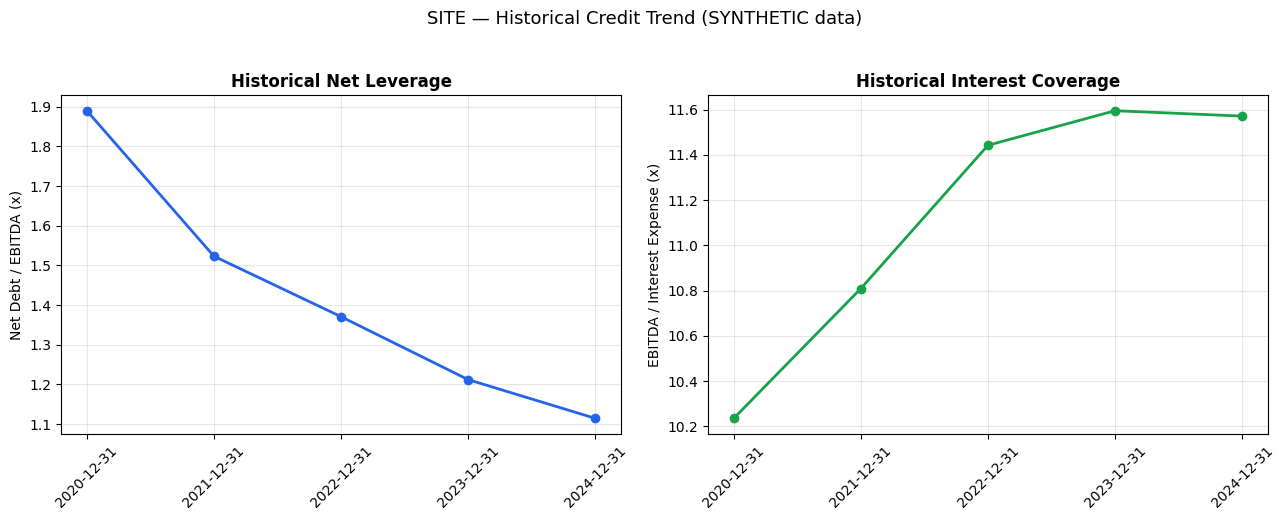

In [9]:
# =====================================================================================
# SECTION 8: VISUALIZATION — HISTORICAL LEVERAGE & COVERAGE TREND
# =====================================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(hist_metrics.index, hist_metrics["NetDebt/EBITDA"], marker="o", linewidth=2, color="#2563eb")
axes[0].set_title("Historical Net Leverage", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Net Debt / EBITDA (x)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(alpha=0.3)

axes[1].plot(hist_metrics.index, hist_metrics["EBITDA/Interest"], marker="o", linewidth=2, color="#16a34a")
axes[1].set_title("Historical Interest Coverage", fontsize=12, fontweight="bold")
axes[1].set_ylabel("EBITDA / Interest Expense (x)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(alpha=0.3)

plt.suptitle(f"{CONFIG['TICKER']} — Historical Credit Trend ({DATA_SOURCE} data)", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()


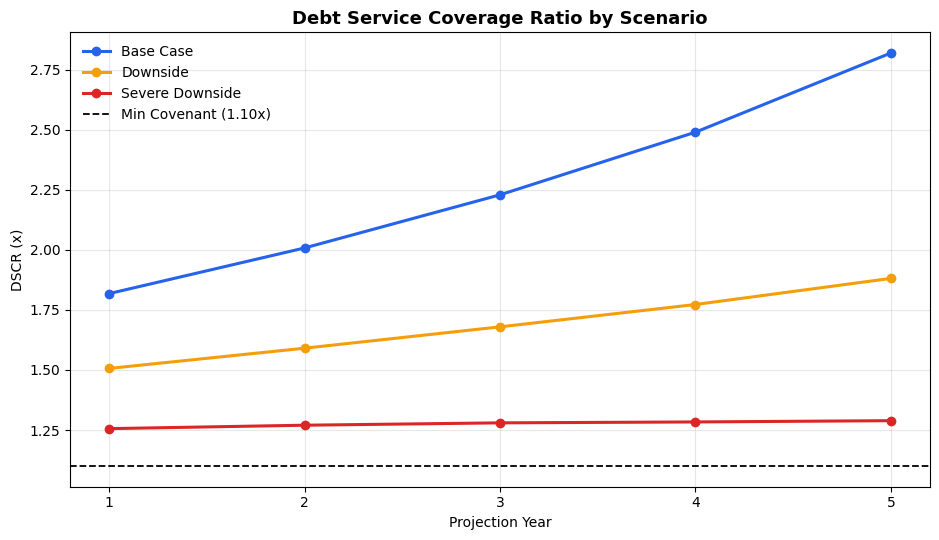

In [10]:
# =====================================================================================
# SECTION 9: VISUALIZATION — DSCR BY SCENARIO
# =====================================================================================

fig, ax = plt.subplots(figsize=(9.5, 5.5))
colors = {"Base Case": "#2563eb", "Downside": "#f59e0b", "Severe Downside": "#dc2626"}

for name, grp in scenario_df.groupby("Scenario"):
    ax.plot(grp["Year"], grp["DSCR"], marker="o", linewidth=2.2, label=name, color=colors[name])

ax.axhline(CONFIG["MIN_DSCR_COVENANT"], color="black", linestyle="--", linewidth=1.3,
           label=f"Min Covenant ({CONFIG['MIN_DSCR_COVENANT']:.2f}x)")
ax.set_title("Debt Service Coverage Ratio by Scenario", fontsize=13, fontweight="bold")
ax.set_xlabel("Projection Year")
ax.set_ylabel("DSCR (x)")
ax.set_xticks(range(1, CONFIG["TENOR_YEARS"] + 1))
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


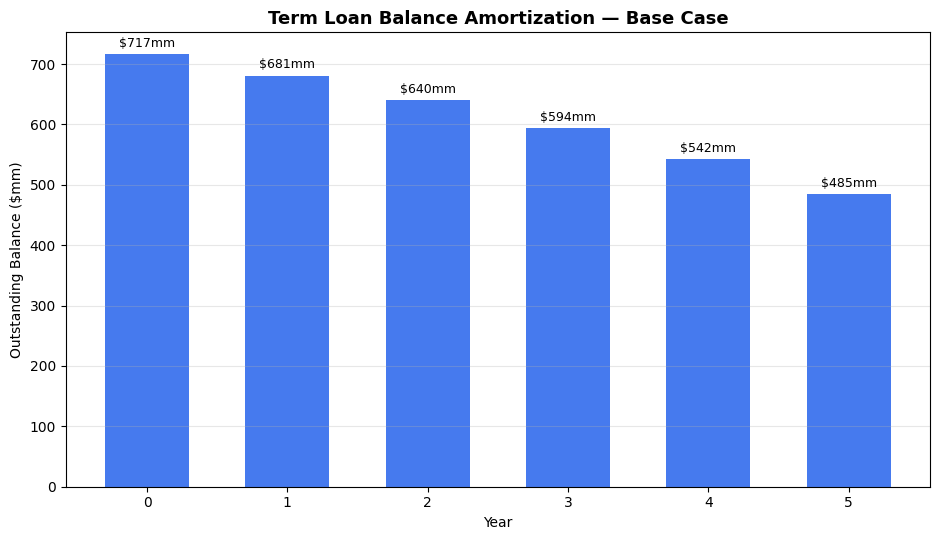

Principal reduction over 5 years: $231.6mm (32.3% paid down)
Remaining refinancing requirement at maturity: $485.2mm


In [11]:
# =====================================================================================
# SECTION 10: VISUALIZATION — AMORTIZATION / BALANCE PAYDOWN (BASE CASE)
# =====================================================================================

base_scenario = scenario_df[scenario_df["Scenario"] == "Base Case"]
years_x = [0] + list(base_scenario["Year"])
balances = [LOAN_AMOUNT] + list(base_scenario["EndBalance"])

fig, ax = plt.subplots(figsize=(9.5, 5.5))
bars = ax.bar(years_x, balances, color="#2563eb", alpha=0.85, width=0.6)
ax.bar_label(bars, fmt="$%.0fmm", padding=3, fontsize=9)
ax.set_title("Term Loan Balance Amortization — Base Case", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Outstanding Balance ($mm)")
ax.set_xticks(years_x)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"Principal reduction over {CONFIG['TENOR_YEARS']} years: "
      f"${LOAN_AMOUNT - balances[-1]:,.1f}mm ({(1 - balances[-1]/LOAN_AMOUNT)*100:.1f}% paid down)")
print(f"Remaining refinancing requirement at maturity: ${balances[-1]:,.1f}mm")


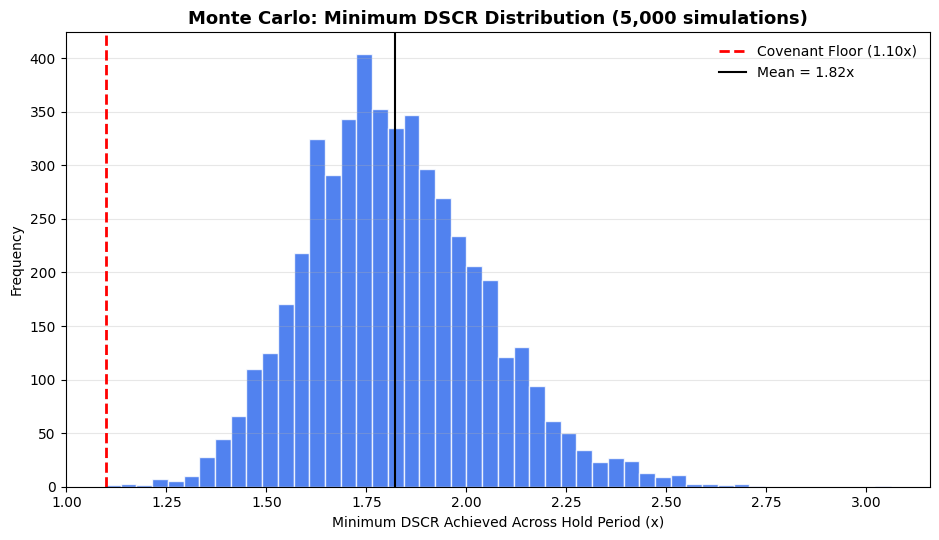

P(covenant breach): 0.02%  |  5th pct: 1.48x  |  95th pct: 2.21x


In [12]:
# =====================================================================================
# SECTION 11: VISUALIZATION — MONTE CARLO MINIMUM DSCR DISTRIBUTION
# =====================================================================================

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.hist(mc_min_dscr, bins=50, color="#2563eb", alpha=0.8, edgecolor="white")
ax.axvline(CONFIG["MIN_DSCR_COVENANT"], color="red", linestyle="--", linewidth=2,
           label=f"Covenant Floor ({CONFIG['MIN_DSCR_COVENANT']:.2f}x)")
ax.axvline(mc_min_dscr.mean(), color="black", linestyle="-", linewidth=1.5,
           label=f"Mean = {mc_min_dscr.mean():.2f}x")
ax.set_title(f"Monte Carlo: Minimum DSCR Distribution ({CONFIG['MC_SIMULATIONS']:,} simulations)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Minimum DSCR Achieved Across Hold Period (x)")
ax.set_ylabel("Frequency")
ax.legend(frameon=False)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"P(covenant breach): {mc_breaches.mean()*100:.2f}%  |  "
      f"5th pct: {np.percentile(mc_min_dscr,5):.2f}x  |  95th pct: {np.percentile(mc_min_dscr,95):.2f}x")


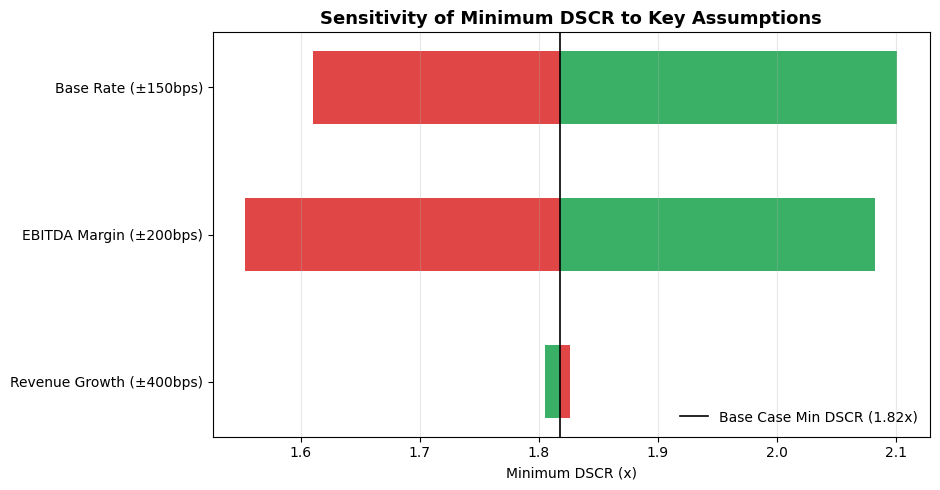

In [13]:
# =====================================================================================
# SECTION 12: VISUALIZATION — SENSITIVITY TORNADO CHART
# =====================================================================================

base_min_dscr = scenario_summary_df.loc[scenario_summary_df["Scenario"] == "Base Case", "Min DSCR"].iloc[0]

def min_dscr_for_shock(growth_shock=0.0, margin_shock=0.0, rate_shock=0.0):
    df_s, _ = run_scenario("sensitivity", growth_shock=growth_shock, margin_shock=margin_shock, rate_shock=rate_shock)
    return df_s["DSCR"].min()

sensitivities = {
    "Revenue Growth (±400bps)": (min_dscr_for_shock(growth_shock=-0.04), min_dscr_for_shock(growth_shock=0.04)),
    "EBITDA Margin (±200bps)":  (min_dscr_for_shock(margin_shock=-0.02), min_dscr_for_shock(margin_shock=0.02)),
    "Base Rate (±150bps)":      (min_dscr_for_shock(rate_shock=0.015),  min_dscr_for_shock(rate_shock=-0.015)),
}

labels = list(sensitivities.keys())
lows = [sensitivities[k][0] for k in labels]
highs = [sensitivities[k][1] for k in labels]

fig, ax = plt.subplots(figsize=(9.5, 5))
y_pos = np.arange(len(labels))
for i, (lo, hi) in enumerate(zip(lows, highs)):
    ax.barh(i, hi - base_min_dscr, left=base_min_dscr, color="#16a34a", alpha=0.85, height=0.5)
    ax.barh(i, lo - base_min_dscr, left=base_min_dscr, color="#dc2626", alpha=0.85, height=0.5)

ax.axvline(base_min_dscr, color="black", linewidth=1.2, label=f"Base Case Min DSCR ({base_min_dscr:.2f}x)")
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_title("Sensitivity of Minimum DSCR to Key Assumptions", fontsize=13, fontweight="bold")
ax.set_xlabel("Minimum DSCR (x)")
ax.legend(frameon=False, loc="lower right")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()


## 12. Performance Metrics

The metrics that ultimately drive an underwriting decision are consolidated below:

- **Opening vs. proposed leverage** — how much incremental debt is being layered on
- **LTM interest coverage** — existing cushion before the new facility
- **Minimum DSCR** under Base, Downside, and Severe Downside scenarios
- **Monte Carlo probability of covenant breach** — the single most decision-relevant statistic
- **Refinancing balloon size at maturity** — the size of the "exit" the borrower must execute


In [14]:
# =====================================================================================
# SECTION 13: PERFORMANCE METRICS SUMMARY
# =====================================================================================

metrics_summary = {
    "Opening Net Leverage (x)": OPENING_LEVERAGE,
    "Proposed Leverage at Close (x)": CONFIG["LEVERAGE_MULTIPLE"],
    "LTM Interest Coverage (x)": hist_metrics["EBITDA/Interest"].iloc[-1],
    "All-in Coupon (%)": ALL_IN_RATE * 100,
    "Base Case Min DSCR (x)": scenario_summary_df.loc[scenario_summary_df["Scenario"] == "Base Case", "Min DSCR"].iloc[0],
    "Downside Min DSCR (x)": scenario_summary_df.loc[scenario_summary_df["Scenario"] == "Downside", "Min DSCR"].iloc[0],
    "Severe Downside Min DSCR (x)": scenario_summary_df.loc[scenario_summary_df["Scenario"] == "Severe Downside", "Min DSCR"].iloc[0],
    "Monte Carlo P(Covenant Breach) (%)": mc_breaches.mean() * 100,
    "Refi Balloon at Maturity, Base Case (% of orig.)": base_refi / LOAN_AMOUNT * 100,
}

metrics_df = pd.DataFrame.from_dict(metrics_summary, orient="index", columns=["Value"])
metrics_df.round(2)


,Value
Opening Net Leverage (x),1.11
Proposed Leverage at Close (x),4.00
LTM Interest Coverage (x),11.57
All-in Coupon (%),8.80
Base Case Min DSCR (x),1.82
Downside Min DSCR (x),1.51
Severe Downside Min DSCR (x),1.26
Monte Carlo P(Covenant Breach) (%),0.02
"Refi Balloon at Maturity, Base Case (% of orig.)",67.69


## 13. Final Deliverables

Running this notebook end to end produces:

1. A **cleaned historical credit profile** for the borrower
2. A **fully structured loan** (sizing, pricing, amortization, covenant)
3. A **5-year DSCR projection** under three deterministic scenarios
4. A **Monte Carlo–based probability of covenant breach**
5. **Five professional charts** suitable for a credit committee deck
6. An **auto-generated, one-page credit memo** with a preliminary recommendation (below)

## 14. Auto-Generated Credit Memo


In [15]:
# =====================================================================================
# SECTION 14: FINAL DELIVERABLE — AUTO-GENERATED CREDIT MEMO
# =====================================================================================

def generate_credit_memo(ticker: str, data_source: str, hist_metrics: pd.DataFrame, config: dict,
                          loan_amount: float, ltm_ebitda: float, scenario_summary_df: pd.DataFrame,
                          mc_breach_prob: float, base_refi: float) -> str:
    """Compile all upstream analysis into a formatted, one-page credit memo with
    rule-based risk flags and a preliminary recommendation."""

    opening_lev = hist_metrics["NetDebt/EBITDA"].iloc[-1]
    coverage = hist_metrics["EBITDA/Interest"].iloc[-1]
    base_min_dscr = scenario_summary_df.loc[scenario_summary_df["Scenario"] == "Base Case", "Min DSCR"].iloc[0]
    severe_min_dscr = scenario_summary_df.loc[scenario_summary_df["Scenario"] == "Severe Downside", "Min DSCR"].iloc[0]
    refi_pct = base_refi / loan_amount * 100

    flags = []
    if config["LEVERAGE_MULTIPLE"] > 5.5:
        flags.append("Total leverage exceeds typical middle-market threshold of 5.0x-5.5x.")
    if severe_min_dscr < config["MIN_DSCR_COVENANT"]:
        flags.append("DSCR breaches the covenant floor under the severe downside scenario.")
    if mc_breach_prob > 5.0:
        flags.append(f"Monte Carlo simulation shows elevated covenant breach probability ({mc_breach_prob:.1f}%).")
    if refi_pct > 60:
        flags.append(f"Material refinancing/balloon risk at maturity ({refi_pct:.0f}% of original principal outstanding).")
    if not flags:
        flags.append("No material red flags identified under current structuring assumptions.")

    recommend = ("PROCEED" if (mc_breach_prob < 5.0 and config["LEVERAGE_MULTIPLE"] <= 5.5 and severe_min_dscr >= 1.0)
                 else "PROCEED WITH CAUTION / RESTRUCTURE")

    memo = f"""
{'='*78}
CREDIT MEMO (DRAFT) — Borrower Proxy: {ticker}  |  Data Source: {data_source}
{'='*78}

TRANSACTION SUMMARY
  Facility:               Senior Secured Term Loan
  Proposed Amount:        ${loan_amount:,.1f}mm ({config['LEVERAGE_MULTIPLE']:.2f}x LTM EBITDA)
  LTM EBITDA:             ${ltm_ebitda:,.1f}mm
  Pricing:                SOFR + {config['SPREAD']*10000:.0f}bps (all-in {(config['BASE_RATE']+config['SPREAD'])*100:.2f}%)
  Tenor:                  {config['TENOR_YEARS']} years
  Amortization:           {config['MANDATORY_AMORT_PCT']*100:.1f}% p.a. mandatory + {config['CASH_SWEEP_PCT']*100:.0f}% excess cash flow sweep
  Covenant:               Minimum DSCR of {config['MIN_DSCR_COVENANT']:.2f}x, tested annually

CREDIT PROFILE AT CLOSE
  Opening Net Leverage:   {opening_lev:.2f}x
  LTM Interest Coverage:  {coverage:.2f}x

PROJECTED COVERAGE (Scheduled DSCR, excl. bullet)
  Base Case Min DSCR:              {base_min_dscr:.2f}x
  Severe Downside Min DSCR:        {severe_min_dscr:.2f}x
  Monte Carlo P(Covenant Breach):  {mc_breach_prob:.2f}%
  Refinancing Balance at Maturity (Base Case): {refi_pct:.1f}% of original principal

KEY RISK FLAGS
""" + "\n".join(f"  - {f}" for f in flags) + f"""

PRELIMINARY RECOMMENDATION: {recommend}

  (This memo is auto-generated for illustrative/educational purposes and does
   not constitute investment advice or a real underwriting decision.)
{'='*78}
"""
    return memo


credit_memo = generate_credit_memo(
    CONFIG["TICKER"], DATA_SOURCE, hist_metrics, CONFIG, LOAN_AMOUNT, LTM_EBITDA,
    scenario_summary_df, mc_breaches.mean() * 100, base_refi
)
print(credit_memo)



CREDIT MEMO (DRAFT) — Borrower Proxy: SITE  |  Data Source: SYNTHETIC

TRANSACTION SUMMARY
  Facility:               Senior Secured Term Loan
  Proposed Amount:        $716.8mm (4.00x LTM EBITDA)
  LTM EBITDA:             $179.2mm
  Pricing:                SOFR + 450bps (all-in 8.80%)
  Tenor:                  5 years
  Amortization:           1.0% p.a. mandatory + 50% excess cash flow sweep
  Covenant:               Minimum DSCR of 1.10x, tested annually

CREDIT PROFILE AT CLOSE
  Opening Net Leverage:   1.11x
  LTM Interest Coverage:  11.57x

PROJECTED COVERAGE (Scheduled DSCR, excl. bullet)
  Base Case Min DSCR:              1.82x
  Severe Downside Min DSCR:        1.26x
  Monte Carlo P(Covenant Breach):  0.02%
  Refinancing Balance at Maturity (Base Case): 67.7% of original principal

KEY RISK FLAGS
  - Material refinancing/balloon risk at maturity (68% of original principal outstanding).

PRELIMINARY RECOMMENDATION: PROCEED

  (This memo is auto-generated for illustrative/educati

## 15. Potential Upgrades

- **Live base rate feed** — replace the static SOFR proxy with a live pull from **FRED** (`SOFR` series)
- **Peer comp benchmarking** — pull comparable leverage multiples from **Financial Modeling Prep** to contextualize the proposed structure against actual market clearing levels
- **Covenant package expansion** — add a leverage covenant (max Net Debt/EBITDA test) alongside the DSCR test
- **Multiple tranches** — extend the loan structuring engine to a unitranche or first-lien/second-lien split
- **Recovery/loss-given-default modeling** — layer a simple LGD assumption onto the Monte Carlo breach probability to estimate **expected loss**, not just breach probability
- **PDF/Word memo export** — pipe the `generate_credit_memo()` output into a formatted Word or PDF document for direct circulation to a credit committee
- **Multi-borrower batch mode** — loop the entire pipeline across a list of tickers to build a **portfolio-level screening tool**

---

## Resume Description

> **Built a private credit underwriting engine (Python) that pulls live SEC EDGAR financial data, structures term loan sizing/pricing/amortization, projects 5-year cash flow and DSCR under multiple stress scenarios, and runs a 5,000-path Monte Carlo simulation to quantify covenant-breach probability — auto-generating a one-page credit memo with a preliminary recommendation.**

This single sentence maps directly onto the day-to-day workflow at middle-market direct lenders, BDCs, and infrastructure credit funds, and is a strong, concrete talking point for interviews in that space.

---

*This notebook is for educational/illustrative purposes. It uses a public company as a borrower "proxy" purely to demonstrate the modeling framework — it is not a real underwriting analysis of any actual credit.*
